# Fashion-MNIST Image Classification with PyTorch

**Author:** Mehdy Mokhtari  
**Course:** Fundamentals of Computer Vision  
**Assignment:** Homework 4 – Simple Neural Network Design & Evaluation  
**Date:** 1404–1405 (Fall Semester)

## Project Overview
This notebook presents an end-to-end implementation of a **multi-class image classification system** using a **fully connected neural network** in **PyTorch**, evaluated on the **Fashion-MNIST** dataset.

The objective of this project is to demonstrate a practical and structured deep learning workflow, including:
- Dataset loading and inspection
- Neural network architecture design
- Training and optimization
- Model evaluation and error analysis
- Performance visualization and improvement strategies

The focus is on **clarity, correctness, and analytical reasoning**, following standard practices used in real-world computer vision and machine learning projects.


In [1]:
# all the pip installs should be here and any general libraies used 

## 1. Dataset Loading

In this section, the **Fashion-MNIST** dataset is loaded using `torchvision.datasets`.
Fashion-MNIST is a standard benchmark dataset consisting of grayscale images representing 10 categories of clothing items.

**Dataset characteristics:**
- 60,000 training images
- 10,000 test images
- Image resolution: 28×28
- Single-channel (grayscale)
- 10 balanced classes

The dataset is prepared using appropriate transformations and wrapped in PyTorch `DataLoader`s to enable efficient batch-based training and evaluation.


In [2]:
from torchvision import datasets , transforms
import os

transform = transforms.Compose(
    [
        transforms.ToTensor(), 
        transforms.Normalize((0.5, ), (0.5, ))
    ]
)

data_dir = os.path.join('data', 'datasets')

train_ds = datasets.FashionMNIST(data_dir, download=True, train=True, transform=transform)
test_ds = datasets.FashionMNIST(data_dir, download=True, train=False, transform=transform)

In [3]:
print(train_ds)

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: data\datasets
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5,), std=(0.5,))
           )


## 1.5. Data Exploration & Preprocessing

Before training, the dataset is explored to ensure correctness and consistency.
This includes:
- Inspecting batch dimensions
- Visualizing sample images with labels
- Verifying input tensor shapes

Each image is **flattened from 28×28 to a 784-dimensional vector** to match the input requirements of a fully connected neural network.

This step ensures a clear understanding of the data structure and prevents shape-related issues during model training.


In [4]:
print(train_ds.classes)
class_names = train_ds.classes

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [5]:
print(train_ds)

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: data\datasets
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5,), std=(0.5,))
           )


In [6]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=True)

images, labels = next(iter(train_loader))

print("Images batch shape:", images.shape)
print("Labels batch shape:", labels.shape)


Images batch shape: torch.Size([32, 1, 28, 28])
Labels batch shape: torch.Size([32])


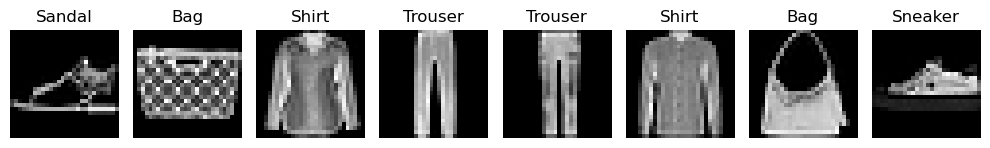

In [7]:
import matplotlib.pyplot as plt

class_names = train_ds.classes

plt.figure(figsize=(10, 4))

for i in range(8):
    plt.subplot(1, 8, i + 1)
    img = images[i].squeeze()  # remove channel dimension
    plt.imshow(img, cmap="gray")
    plt.title(class_names[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()


In [8]:
# Single image shape
single_image, single_label = train_ds[0]

print("Single image shape:", single_image.shape)
print("Flattened image shape:", single_image.view(-1).shape)


Single image shape: torch.Size([1, 28, 28])
Flattened image shape: torch.Size([784])


## 2. Neural Network Architecture Design

A multi-layer fully connected neural network is implemented using PyTorch's `nn.Module`.

**Architecture:**
- Input layer: 784 units (flattened image)
- Hidden layer 1: 256 units + ReLU
- Hidden layer 2: 128 units + ReLU
- Output layer: 10 units (one per class)

The final layer outputs raw logits, allowing `CrossEntropyLoss` to internally apply softmax during training.

The model structure and total number of parameters are printed and analyzed to ensure correctness and efficiency.


In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FashionMNIST_FC(nn.Module):
    def __init__(self):
        super(FashionMNIST_FC, self).__init__()
        self.fc1 = nn.Linear(28*28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = FashionMNIST_FC()
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total trainable parameters: {total_params}")
print("""\nExplanation:
The model first **flattens each 28×28 image into a 784-dimensional vector** to serve as input for the fully connected layers. The **first hidden layer** maps these inputs to 256 units with a ReLU activation to learn complex features. The **second hidden layer** reduces the representation to 128 units, again applying ReLU for non-linear transformations. The **output layer** maps the 128 features to 10 logits, corresponding to the 10 clothing classes. These logits are used with `CrossEntropyLoss` to compute the classification error during training.
""")

FashionMNIST_FC(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)
Total trainable parameters: 235146

Explanation:
The model first **flattens each 28×28 image into a 784-dimensional vector** to serve as input for the fully connected layers. The **first hidden layer** maps these inputs to 256 units with a ReLU activation to learn complex features. The **second hidden layer** reduces the representation to 128 units, again applying ReLU for non-linear transformations. The **output layer** maps the 128 features to 10 logits, corresponding to the 10 clothing classes. These logits are used with `CrossEntropyLoss` to compute the classification error during training.



## 3. Loss Function & Optimizer

For training the network, the following configuration is used:

- **Loss Function:** `CrossEntropyLoss`  
  Chosen because it is the standard loss function for multi-class classification problems and combines softmax and negative log-likelihood internally.

- **Optimizer:** `Adam`  
  Adam is selected for its adaptive learning rate and stable convergence behavior.

**Learning rate:** 0.001

This setup provides a strong baseline for efficient and reliable training.


In [10]:
LEARNING_RATE = 0.001

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

print("""Explanation:
      CrossEntropyLoss is commonly used for multi-class classification problems, where it measures the difference between the predicted probability distribution (from the model's logits) and the true class distribution (one-hot encoded labels). It combines softmax activation and negative log-likelihood, effectively penalizing the model for incorrect predictions based on how confident the model was in its choice. This loss function helps the model improve by minimizing the error during training.
""")


Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
Explanation:
      CrossEntropyLoss is commonly used for multi-class classification problems, where it measures the difference between the predicted probability distribution (from the model's logits) and the true class distribution (one-hot encoded labels). It combines softmax activation and negative log-likelihood, effectively penalizing the model for incorrect predictions based on how confident the model was in its choice. This loss function helps the model improve by minimizing the error during training.



## 4. Model Training

The model is trained using a custom training loop that includes:
- Switching the model to training mode
- Forward pass for each batch
- Loss computation
- Backpropagation
- Weight updates using the optimizer

Training metrics such as **loss and accuracy** are tracked at each epoch.
A minimum of 10 epochs is used to ensure stable convergence and meaningful performance evaluation.


In [11]:
import torch
from tqdm import tqdm

NUM_EPOCHS = 10

epoch_losses = []
epoch_accs = []

model_path = os.path.join('models', 'epoch_losses.pt')
os.makedirs('models', exist_ok=True)

def train_model(model, train_loader, criterion, optimizer, num_epochs=NUM_EPOCHS):

    epoch_losses.clear()
    epoch_accs.clear()
    model.train()

    for epoch in range(num_epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        for batch_idx, (inputs, labels) in tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch+1}/{num_epochs}"):
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            loss.backward()
            optimizer.step()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader)
        epoch_accuracy = 100 * correct / total
        epoch_losses.append(epoch_loss)
        epoch_accs.append(epoch_accuracy)

        print(f'Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%')

    torch.save(epoch_losses, model_path)
    print("Training loss values saved to 'epoch_losses.pt'.")

train_model(model, train_loader, criterion, optimizer)


Epoch 1/10: 100%|██████████| 1875/1875 [00:42<00:00, 44.32it/s]


Epoch 1/10, Loss: 0.4854, Accuracy: 82.06%


Epoch 2/10: 100%|██████████| 1875/1875 [00:51<00:00, 36.63it/s]


Epoch 2/10, Loss: 0.3664, Accuracy: 86.55%


Epoch 3/10: 100%|██████████| 1875/1875 [00:56<00:00, 33.33it/s]


...

Epoch 8/10, Loss: 0.2470, Accuracy: 90.70%


Epoch 9/10: 100%|██████████| 1875/1875 [00:48<00:00, 38.70it/s]


Epoch 9/10, Loss: 0.2350, Accuracy: 91.19%


Epoch 10/10: 100%|██████████| 1875/1875 [00:49<00:00, 37.54it/s]

Epoch 10/10, Loss: 0.2254, Accuracy: 91.50%
Training loss values saved to 'epoch_losses.pt'.


## 5. Model Evaluation & Error Analysis

After training, the model is evaluated on the **test dataset** using evaluation mode to disable gradient computation.

Evaluation includes:
- Computing test accuracy
- Displaying sample predictions alongside ground-truth labels
- Inspecting incorrectly classified samples

Special attention is given to visually similar clothing categories, which helps explain common sources of classification errors and model limitations.


In [12]:
import torch

wrong_predictions = []
correct_predictions = []

def evaluate_model(model, test_loader, criterion, classes):
    model.eval()
    correct = 0
    total = 0
    running_loss = 0.0
    wrong_predictions.clear()
    correct_predictions.clear()

    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            wrong_preds = [(inputs[i], predicted[i], labels[i]) for i in range(len(labels)) if predicted[i] != labels[i]]
            correct_preds = [(inputs[i], predicted[i], labels[i]) for i in range(len(labels)) if predicted[i] == labels[i]]

            wrong_predictions.extend(wrong_preds)
            correct_predictions.extend(correct_preds)

    accuracy = 100 * correct / total
    avg_loss = running_loss / len(test_loader)

    print(f"Test Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}%")

    return accuracy, avg_loss


accuracy, avg_loss = evaluate_model(model, test_loader, criterion, train_ds.classes)


Test Loss: 0.3476, Accuracy: 88.51%


Correct Predictions (Sampled):


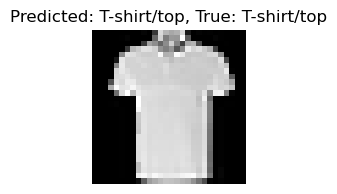

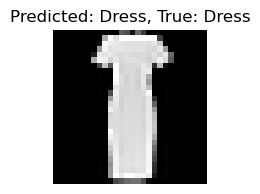

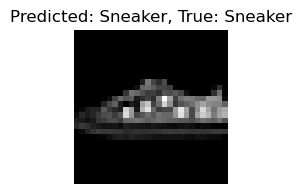

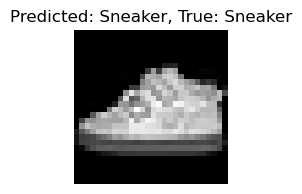

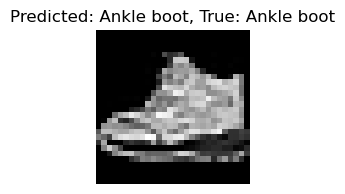

Incorrect Predictions (Sampled):


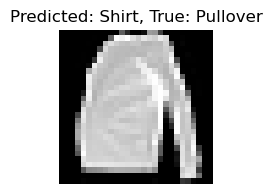

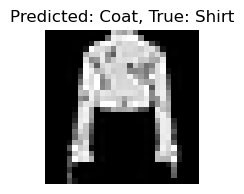

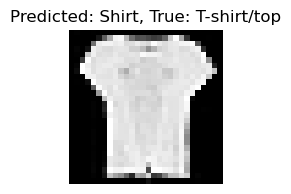

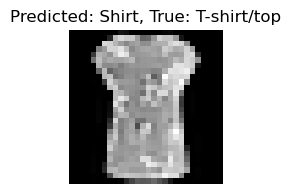

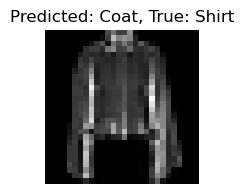

In [13]:
def display_predictions(wrong_predictions, correct_predictions, classes):
    print("Correct Predictions (Sampled):")
    for i, (img, pred, true) in enumerate(correct_predictions[:5]):  
        img = img.squeeze()  
        plt.figure(figsize=(2, 2))
        plt.imshow(img, cmap='gray')
        plt.title(f"Predicted: {classes[pred.item()]}, True: {classes[true.item()]}")
        plt.axis('off')
        plt.show()

    print("Incorrect Predictions (Sampled):")
    for i, (img, pred, true) in enumerate(wrong_predictions[:5]): 
        img = img.squeeze() 
        plt.figure(figsize=(2, 2))
        plt.imshow(img, cmap='gray')
        plt.title(f"Predicted: {classes[pred.item()]}, True: {classes[true.item()]}")
        plt.axis('off')
        plt.show()

display_predictions(wrong_predictions, correct_predictions, train_ds.classes)

```text
the shirt , t-shirt and the coat were sometimes missclassifed. 

## 6. Visualization

Training dynamics are analyzed through visualization:
- Training loss vs. epoch
- Accuracy vs. epoch

These plots are used to assess convergence behavior and identify signs of overfitting.



C:\Users\NoteBook\AppData\Local\Temp\ipykernel_9832\1570267835.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  epoch_losses = torch.load(model_path)


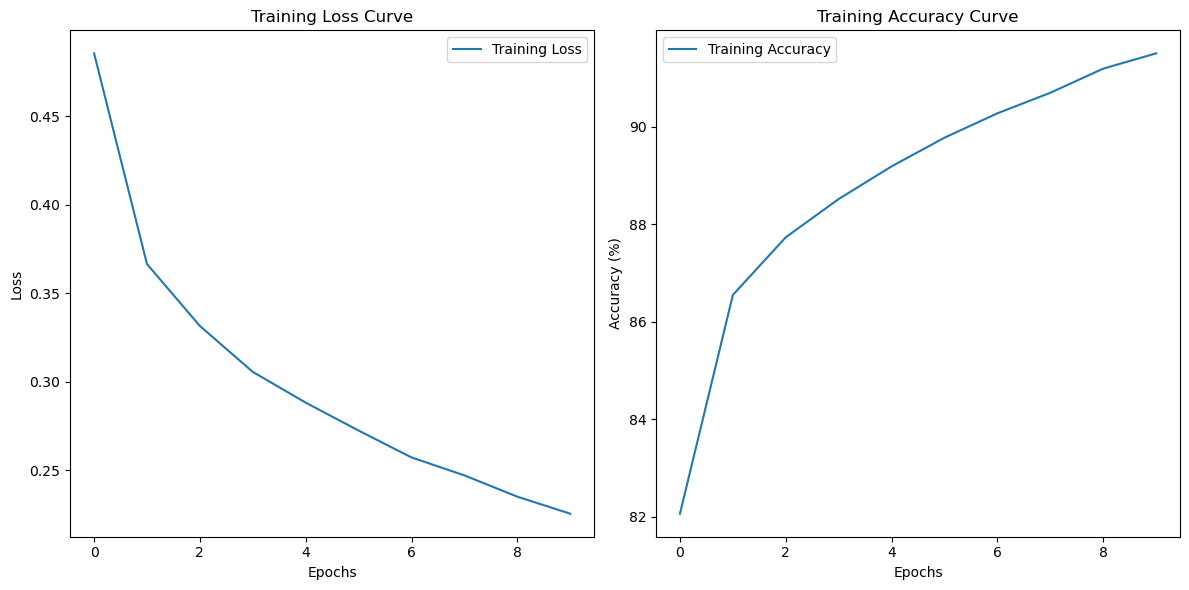

Explanation:
    The model hasn't overfit because the plots are showing convergence and the test accuracy is reasonably high compared to the training accuracy. If the training accuracy was significantly higher than the test accuracy, it would indicate overfitting. However, since both accuracies are relatively close, it suggests that the model generalizes well to unseen data. and the loss curves show a steady decrease in loss over epochs, indicating that the model is learning effectively without overfitting.  



In [ ]:
import matplotlib.pyplot as plt

def plot_training_curves(epoch_losses, epoch_accs):
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(epoch_losses, label='Training Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training Loss Curve')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epoch_accs, label='Training Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.title('Training Accuracy Curve')
    plt.legend()

    plt.tight_layout()
    plt.show()


epoch_losses = torch.load(model_path)

plot_training_curves(epoch_losses, epoch_accs)


```text
The model hasn't overfit because the plots are showing convergence and the test accuracy is reasonably high compared to the training accuracy. If the training accuracy was significantly higher than the test accuracy, it would indicate overfitting. However, since both accuracies are relatively close, it suggests that the model generalizes well to unseen data. and the loss curves show a steady decrease in loss over epochs, indicating that the model is learning effectively without overfitting.  


## 7. Model Improvement


Optional improvements are explored, including:
- Dropout for regularization
- Batch Normalization
- Hyperparameter tuning (learning rate, optimizer choice)
- Adjusting the number of neurons in hidden layers

The impact of these changes is analyzed and compared against the baseline model.

In [15]:
import os
import torch
import torch.nn as nn
from tqdm import tqdm

def build_criterion():
    return nn.CrossEntropyLoss()

def train_model(
    model,
    train_loader,
    optimizer,
    criterion,
    num_epochs,
    model_name,
    save_dir="models",
    device="cpu"
):

    model.to(device)
    model.train()

    epoch_losses = []
    epoch_accuracies = []

    os.makedirs(save_dir, exist_ok=True)

    for epoch in range(num_epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in tqdm(
            train_loader,
            desc=f"[{model_name}] Epoch {epoch+1}/{num_epochs}"
        ):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100.0 * correct / total

        epoch_losses.append(epoch_loss)
        epoch_accuracies.append(epoch_acc)

        print(
            f"[{model_name}] "
            f"Epoch {epoch+1}/{num_epochs} | "
            f"Loss: {epoch_loss:.4f} | "
            f"Accuracy: {epoch_acc:.2f}%"
        )

    torch.save(epoch_losses, os.path.join(save_dir, f"{model_name}_train_losses.pt"))
    torch.save(epoch_accuracies, os.path.join(save_dir, f"{model_name}_train_accuracies.pt"))

    print(f"[{model_name}] Training finished.")


def evaluate_model(
    model,
    test_loader,
    criterion,
    model_name,
    save_dir="models",
    device="cpu"
):

    model.to(device)
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = running_loss / len(test_loader)
    accuracy = 100.0 * correct / total

    # Save evaluation metrics
    results = {
        "test_loss": avg_loss,
        "test_accuracy": accuracy
    }
    torch.save(results, os.path.join(save_dir, f"{model_name}_eval.pt"))

    print(f"[{model_name}] Test Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}%")

    return accuracy, avg_loss


### Dropout added

In [16]:
class FashionMNIST_FC_Dropout(nn.Module):
    def __init__(self):
        super(FashionMNIST_FC_Dropout, self).__init__()
        self.fc1 = nn.Linear(28*28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)
        self.dropout = nn.Dropout(p=0.3)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)  
        x = F.relu(self.fc2(x))
        x = self.dropout(x)  
        x = self.fc3(x)
        return x

model_name = "fc_dropout"

model = FashionMNIST_FC_Dropout()
criterion = build_criterion()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_model(
    model=model,
    train_loader=train_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=NUM_EPOCHS,
    model_name=model_name
)

evaluate_model(
    model=model,
    test_loader=test_loader,
    criterion=criterion,
    model_name=model_name
)


[fc_dropout] Epoch 1/10: 100%|██████████| 1875/1875 [00:44<00:00, 41.70it/s]


[fc_dropout] Epoch 1/10 | Loss: 0.5672 | Accuracy: 79.22%


[fc_dropout] Epoch 2/10: 100%|██████████| 1875/1875 [00:50<00:00, 37.47it/s]


[fc_dropout] Epoch 2/10 | Loss: 0.4470 | Accuracy: 83.70%


[fc_dropout] Epoch 3/10: 100%|██████████| 1875/1875 [00:52<00:00, 35.70it/s]


...

[fc_dropout] Epoch 9/10: 100%|██████████| 1875/1875 [00:20<00:00, 89.32it/s] 


[fc_dropout] Epoch 9/10 | Loss: 0.3453 | Accuracy: 87.36%


[fc_dropout] Epoch 10/10: 100%|██████████| 1875/1875 [00:21<00:00, 87.08it/s] 


[fc_dropout] Epoch 10/10 | Loss: 0.3358 | Accuracy: 87.64%
[fc_dropout] Training finished.
[fc_dropout] Test Loss: 0.3580, Accuracy: 87.44%


(87.44, 0.35799166533988885)

```text 
Explanation:
Introducing dropout added regularization by randomly deactivating neurons during training, which reduced co-adaptation between features. This led to more similar training and test accuracies, indicating improved control over overfitting and better generalization behavior.

The slight decrease in both training and test accuracy is expected, as dropout intentionally injects noise into the learning process and limits the model’s effective capacity. In this case, the baseline model was not severely overfitting, so the regularization effect of dropout traded a small amount of accuracy for more stable and robust learning.


### Batch Normalization added

In [17]:
class FashionMNIST_FC_BatchNorm(nn.Module):
    def __init__(self):
        super(FashionMNIST_FC_BatchNorm, self).__init__()
        self.fc1 = nn.Linear(28*28, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.bn1(self.fc1(x))) 
        x = F.relu(self.bn2(self.fc2(x))) 
        x = self.fc3(x)
        return x

model_name = "fc_batchnorm"

model = FashionMNIST_FC_BatchNorm()
criterion = build_criterion()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_model(
    model,
    train_loader,
    optimizer,
    criterion,
    num_epochs=NUM_EPOCHS,
    model_name=model_name
)

evaluate_model(
    model,
    test_loader,
    criterion,
    model_name
)



[fc_batchnorm] Epoch 1/10: 100%|██████████| 1875/1875 [00:17<00:00, 106.91it/s]


[fc_batchnorm] Epoch 1/10 | Loss: 0.4644 | Accuracy: 83.34%


[fc_batchnorm] Epoch 2/10: 100%|██████████| 1875/1875 [00:43<00:00, 42.74it/s]


[fc_batchnorm] Epoch 2/10 | Loss: 0.3526 | Accuracy: 87.03%


[fc_batchnorm] Epoch 3/10: 100%|██████████| 1875/1875 [00:54<00:00, 34.62it/s]


...

[fc_batchnorm] Epoch 9/10: 100%|██████████| 1875/1875 [00:13<00:00, 134.55it/s]


[fc_batchnorm] Epoch 9/10 | Loss: 0.2145 | Accuracy: 91.92%


[fc_batchnorm] Epoch 10/10: 100%|██████████| 1875/1875 [00:14<00:00, 125.92it/s]


[fc_batchnorm] Epoch 10/10 | Loss: 0.2037 | Accuracy: 92.16%
[fc_batchnorm] Training finished.
[fc_batchnorm] Test Loss: 0.3316, Accuracy: 88.53%


(88.53, 0.3316286203150932)

```text
Explanation:
Adding Batch Normalization stabilized and accelerated the training process by normalizing intermediate activations, which allowed the optimizer to converge more effectively. As a result, the model achieved higher training accuracy due to improved gradient flow and reduced internal covariate shift.

However, the lack of improvement in test accuracy indicates that Batch Normalization primarily helped the model fit the training data better, without enhancing generalization. This suggests that the model was not limited by optimization difficulties, but rather by its representational bias (fully connected architecture) or the nature of the dataset. In this setting, Batch Normalization improved optimization efficiency but did not address the underlying factors affecting test performance.


### Increased number of neurons

In [18]:
class FashionMNIST_FC_LargerWidth(nn.Module):
    def __init__(self):
        super(FashionMNIST_FC_LargerWidth, self).__init__()
        self.fc1 = nn.Linear(28*28, 512)  
        self.fc2 = nn.Linear(512, 256)  
        self.fc3 = nn.Linear(256, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model_name = "fc_larger_width"

model_larger_width = FashionMNIST_FC_LargerWidth()

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_larger_width.parameters(), lr=0.001)

train_model(
    model=model_larger_width,
    train_loader=train_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=NUM_EPOCHS,
    model_name=model_name
)

accuracy, avg_loss = evaluate_model(
    model=model_larger_width,
    test_loader=test_loader,
    criterion=criterion,
    model_name=model_name
)

print("Accuracy of model with larger width:", accuracy)


[fc_larger_width] Epoch 1/10: 100%|██████████| 1875/1875 [00:18<00:00, 103.39it/s]


[fc_larger_width] Epoch 1/10 | Loss: 0.4817 | Accuracy: 82.33%


[fc_larger_width] Epoch 2/10: 100%|██████████| 1875/1875 [00:20<00:00, 90.53it/s]


[fc_larger_width] Epoch 2/10 | Loss: 0.3681 | Accuracy: 86.30%


[fc_larger_width] Epoch 3/10: 100%|██████████| 1875/1875 [00:20<00:00, 90.19it/s]


...

[fc_larger_width] Epoch 8/10 | Loss: 0.2428 | Accuracy: 90.75%


[fc_larger_width] Epoch 9/10: 100%|██████████| 1875/1875 [00:20<00:00, 89.55it/s]


[fc_larger_width] Epoch 9/10 | Loss: 0.2275 | Accuracy: 91.27%


[fc_larger_width] Epoch 10/10: 100%|██████████| 1875/1875 [00:21<00:00, 85.44it/s]


[fc_larger_width] Epoch 10/10 | Loss: 0.2182 | Accuracy: 91.69%
[fc_larger_width] Training finished.
[fc_larger_width] Test Loss: 0.3501, Accuracy: 88.66%
Accuracy of model with larger width: 88.66


```text
Explanation:
Increasing the width of the fully connected layers enhanced the model’s representational capacity, allowing it to learn more expressive feature mappings from the input data. This resulted in a slight improvement in accuracy, indicating that the baseline model benefited from additional neurons.

However, the improvement was modest, suggesting diminishing returns from simply increasing width. This implies that while additional capacity helps, the task is not strongly limited by model width, and further gains likely require architectural changes rather than continued parameter scaling.


### Decrease number of nuerons

In [19]:
class FashionMNIST_FC_SmallerWidth(nn.Module):
    def __init__(self):
        super(FashionMNIST_FC_SmallerWidth, self).__init__()
        self.fc1 = nn.Linear(28*28, 128) 
        self.fc2 = nn.Linear(128, 64)    
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model_name = "fc_smaller_width"

model_smaller_width = FashionMNIST_FC_SmallerWidth()

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_smaller_width.parameters(), lr=0.001)

train_model(
    model=model_smaller_width,
    train_loader=train_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=NUM_EPOCHS,
    model_name=model_name
)

accuracy, avg_loss = evaluate_model(
    model=model_smaller_width,
    test_loader=test_loader,
    criterion=criterion,
    model_name=model_name
)

print("Accuracy of model with smaller width:", accuracy)



[fc_smaller_width] Epoch 1/10: 100%|██████████| 1875/1875 [00:11<00:00, 159.75it/s]


[fc_smaller_width] Epoch 1/10 | Loss: 0.4972 | Accuracy: 81.89%


[fc_smaller_width] Epoch 2/10: 100%|██████████| 1875/1875 [00:12<00:00, 144.48it/s]


[fc_smaller_width] Epoch 2/10 | Loss: 0.3750 | Accuracy: 86.14%


[fc_smaller_width] Epoch 3/10: 100%|██████████| 1875/1875 [00:11<00:00, 168.07it/s]


...

[fc_smaller_width] Epoch 8/10 | Loss: 0.2549 | Accuracy: 90.47%


[fc_smaller_width] Epoch 9/10: 100%|██████████| 1875/1875 [00:11<00:00, 160.92it/s]


[fc_smaller_width] Epoch 9/10 | Loss: 0.2427 | Accuracy: 90.84%


[fc_smaller_width] Epoch 10/10: 100%|██████████| 1875/1875 [00:10<00:00, 173.71it/s]


[fc_smaller_width] Epoch 10/10 | Loss: 0.2370 | Accuracy: 91.06%
[fc_smaller_width] Training finished.
[fc_smaller_width] Test Loss: 0.3395, Accuracy: 88.40%
Accuracy of model with smaller width: 88.4


```text
Explanation:
Reducing the width of the fully connected layers decreased the model’s representational capacity, limiting its ability to learn complex feature interactions in the data. As a result, the training process was slightly constrained, leading to a small drop in accuracy. However, since the performance remained close to the baseline, this suggests that the original model was somewhat over-parameterized and that FashionMNIST can be learned reasonably well with a smaller network.

The minimal performance degradation indicates that the task does not require a large number of neurons to achieve competitive results, and that a compact model can still generalize effectively. This trade-off highlights that reducing model size can improve efficiency with only a marginal loss in accuracy.


### Optimizer and learning rate changed

In [ ]:
import torch.optim as optim

class FashionMNIST_FC_OptimizerChange(nn.Module):
    def __init__(self):
        super(FashionMNIST_FC_OptimizerChange, self).__init__()
        self.fc1 = nn.Linear(28*28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model_name = "fc_lr_0005"

model = FashionMNIST_FC_OptimizerChange()
criterion = build_criterion()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

train_model(
    model,
    train_loader,
    optimizer,
    criterion,
    num_epochs=NUM_EPOCHS,
    model_name=model_name
)

evaluate_model(
    model,
    test_loader,
    criterion,
    model_name
)


[fc_lr_0005] Epoch 1/10: 100%|██████████| 1875/1875 [00:11<00:00, 163.09it/s]


[fc_lr_0005] Epoch 1/10 | Loss: 0.4943 | Accuracy: 82.12%


[fc_lr_0005] Epoch 2/10: 100%|██████████| 1875/1875 [00:12<00:00, 147.89it/s]


[fc_lr_0005] Epoch 2/10 | Loss: 0.3651 | Accuracy: 86.56%


[fc_lr_0005] Epoch 3/10: 100%|██████████| 1875/1875 [00:11<00:00, 158.42it/s]


...

[fc_lr_0005] Epoch 9/10: 100%|██████████| 1875/1875 [00:12<00:00, 154.60it/s]


[fc_lr_0005] Epoch 9/10 | Loss: 0.2260 | Accuracy: 91.55%


[fc_lr_0005] Epoch 10/10: 100%|██████████| 1875/1875 [00:12<00:00, 149.07it/s]


[fc_lr_0005] Epoch 10/10 | Loss: 0.2151 | Accuracy: 91.93%
[fc_lr_0005] Training finished.
[fc_lr_0005] Test Loss: 0.3350, Accuracy: 88.51%


(88.51, 0.3349518760943565)

```text
Explanation:
Lowering the learning rate from 0.001 to 0.0005 allowed the model to optimize the training loss more smoothly, which led to higher training accuracy. However, since the test accuracy remained unchanged, this suggests that the model’s generalization ability did not improve. In other words, the model learned the training data slightly better, but not in a way that transferred to unseen data.

This behavior indicates that the model was not underfitting, but rather limited by its capacity or the data itself. Reducing the learning rate helped the optimizer find a better local minimum for the training set, yet the learned decision boundaries did not become more general. This often means that hyperparameter tuning alone (learning rate) is insufficient, and architectural changes or regularization are required to improve test performance.


### Final Updated model 

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

class FashionMNIST_FC_Updated(nn.Module):
    def __init__(self):
        super(FashionMNIST_FC_Updated, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.fc2 = nn.Linear(512, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.fc3 = nn.Linear(64, 10)
        self.dropout = nn.Dropout(p=0.3)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)
        x = self.fc3(x)
        return x


model_name = "fc_updated_bn_dropout"

model = FashionMNIST_FC_Updated()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)

train_model(
    model=model,
    train_loader=train_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=NUM_EPOCHS,
    model_name=model_name
)

accuracy, avg_loss = evaluate_model(
    model=model,
    test_loader=test_loader,
    criterion=criterion,
    model_name=model_name
)

[fc_updated_bn_dropout] Epoch 1/10: 100%|██████████| 1875/1875 [00:19<00:00, 95.43it/s] 


[fc_updated_bn_dropout] Epoch 1/10 | Loss: 0.5765 | Accuracy: 81.33%


[fc_updated_bn_dropout] Epoch 2/10: 100%|██████████| 1875/1875 [00:20<00:00, 92.98it/s] 


[fc_updated_bn_dropout] Epoch 2/10 | Loss: 0.4293 | Accuracy: 84.62%


[fc_updated_bn_dropout] Epoch 3/10: 100%|██████████| 1875/1875 [00:18<00:00, 102.87it/s]


...

[fc_updated_bn_dropout] Epoch 8/10 | Loss: 0.3147 | Accuracy: 88.51%


[fc_updated_bn_dropout] Epoch 9/10: 100%|██████████| 1875/1875 [00:18<00:00, 102.72it/s]


[fc_updated_bn_dropout] Epoch 9/10 | Loss: 0.3046 | Accuracy: 88.94%


[fc_updated_bn_dropout] Epoch 10/10: 100%|██████████| 1875/1875 [00:18<00:00, 102.81it/s]


[fc_updated_bn_dropout] Epoch 10/10 | Loss: 0.3005 | Accuracy: 89.01%
[fc_updated_bn_dropout] Training finished.
[fc_updated_bn_dropout] Test Loss: 0.3092, Accuracy: 88.83%
accuracy of final updated model: 88.83
